In [1]:
import os
import shutil
import random
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torch.nn as nn

In [ ]:
BASE_PATH = "E:\M.C.A\Project\AI-Real"
AI_SRC = os.path.join(BASE_PATH, "AiArtData", "AiArtData")
REAL_SRC = os.path.join(BASE_PATH, "RealArt", "RealArt")

TARGET = "data"
SPLITS = {"train": 0.7, "val": 0.15, "test": 0.15}

random.seed(42)

In [ ]:
for split in SPLITS:
    for cls in ["ai", "real"]:
        os.makedirs(os.path.join(TARGET, split, cls), exist_ok=True)

In [2]:
def split_class(src_dir, class_name):
    images = [f for f in os.listdir(src_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    random.shuffle(images)
    n = len(images)

    t1 = int(n * SPLITS["train"])
    t2 = int(n * (SPLITS["train"] + SPLITS["val"]))

    split_map = {
        "train": images[:t1],
        "val": images[t1:t2],
        "test": images[t2:]
    }

    for split, files in split_map.items():
        for f in files:
            shutil.copy(
                os.path.join(src_dir, f),
                os.path.join(TARGET, split, class_name, f)
            )

    print(f"{class_name.upper()} → {n} images")

In [ ]:
split_class(AI_SRC, "ai")
split_class(REAL_SRC, "real")

AI → 536 images
REAL → 434 images


In [ ]:
for split in ["train", "val", "test"]:
    ai = len(os.listdir(f"data/{split}/ai"))
    real = len(os.listdir(f"data/{split}/real"))
    print(f"{split}: AI={ai}, Real={real}")

train: AI=375, Real=303
val: AI=80, Real=65
test: AI=81, Real=66


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
train_dataset = ImageFolder("data/train", transform=train_transforms)
val_dataset   = ImageFolder("data/val", transform=val_test_transforms)
test_dataset  = ImageFolder("data/test", transform=val_test_transforms)

print(train_dataset.class_to_idx)

{'ai': 0, 'real': 1}


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

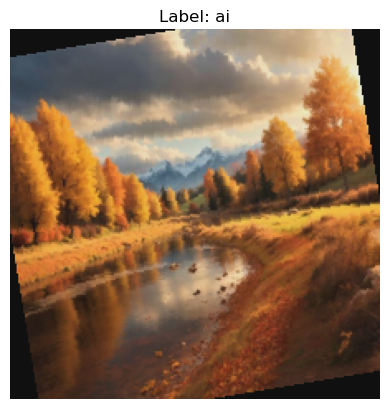

In [6]:
img, label = train_dataset[60]

class_name = train_dataset.classes[label]

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

img = img.permute(1, 2, 0)
img = img * std + mean
img = img.clamp(0, 1)

plt.imshow(img)
plt.title(f"Label: {class_name}")
plt.axis("off")

In [7]:
batch_size = 64
num_classes = 2
num_channels = 3
img_size = 224
patch_size = 16

num_patches = (img_size // patch_size) ** 2  
attention_heads = 8
emd_dim = 256
transformer_blocks = 8
mlp_nodes = 512
learning_rate = 1e-4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)   
print(labels)

torch.Size([64, 3, 224, 224])
tensor([1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1])


In [9]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            in_channels=num_channels,
            out_channels=emd_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.patch_embed(x)          # [B, E, 14, 14]
        x = x.flatten(2)                 # [B, E, 196]
        x = x.transpose(1, 2)            # [B, 196, E]
        return x


In [10]:
class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm(emd_dim)
        self.layer_norm2 = nn.LayerNorm(emd_dim)
        self.multi_head_attention = nn.MultiheadAttention(emd_dim, attention_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(emd_dim,mlp_nodes),
            nn.GELU(),
            nn.Linear(mlp_nodes,emd_dim)
        )

    def forward(self,x):
        residual1 = x
        attention_output = self.multi_head_attention(self.layer_norm1(x),self.layer_norm1(x),self.layer_norm1(x))[0]
        x = attention_output + residual1
        residual2 = x
        mlp_output = self.mlp(self.layer_norm2(x)) 
        x = mlp_output + residual2 
        return x


In [11]:
class VisionTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.patch_embedding = PatchEmbedding()

        self.cls_token = nn.Parameter(torch.randn(1, 1, emd_dim))
        self.positional_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, emd_dim)
        )

        self.transformer_blocks = nn.ModuleList(
            [TransformerEncoder() for _ in range(transformer_blocks)]
        )

        self.norm = nn.LayerNorm(emd_dim)

        self.classifier = nn.Sequential(
            nn.Linear(emd_dim, mlp_nodes),
            nn.ReLU(),
            nn.Linear(mlp_nodes, num_classes)
        )

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.positional_embedding

        for block in self.transformer_blocks:
            x = block(x)

        x = self.norm(x)

        cls_output = x[:, 0]  # CLS token
        return self.classifier(cls_output)


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VisionTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [13]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()  

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)               
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


In [14]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()  

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


In [18]:
EPOCHS = 50

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    #Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_vit_model.pth")


Epoch [1/50] | Train Loss: 0.6556, Train Acc: 0.6188 | Val Loss: 0.6541, Val Acc: 0.6621
Epoch [2/50] | Train Loss: 0.6422, Train Acc: 0.6359 | Val Loss: 0.6693, Val Acc: 0.6414
Epoch [3/50] | Train Loss: 0.6388, Train Acc: 0.6281 | Val Loss: 0.6577, Val Acc: 0.6000
Epoch [4/50] | Train Loss: 0.6493, Train Acc: 0.6422 | Val Loss: 0.6460, Val Acc: 0.6690
Epoch [5/50] | Train Loss: 0.6398, Train Acc: 0.6484 | Val Loss: 0.6524, Val Acc: 0.6759
Epoch [6/50] | Train Loss: 0.6365, Train Acc: 0.6484 | Val Loss: 0.6464, Val Acc: 0.6276
Epoch [7/50] | Train Loss: 0.6365, Train Acc: 0.6547 | Val Loss: 0.6517, Val Acc: 0.6621
Epoch [8/50] | Train Loss: 0.6509, Train Acc: 0.6094 | Val Loss: 0.6380, Val Acc: 0.6897
Epoch [9/50] | Train Loss: 0.6339, Train Acc: 0.6453 | Val Loss: 0.6410, Val Acc: 0.6621
Epoch [10/50] | Train Loss: 0.6314, Train Acc: 0.6531 | Val Loss: 0.6352, Val Acc: 0.6759
Epoch [11/50] | Train Loss: 0.6368, Train Acc: 0.6469 | Val Loss: 0.6344, Val Acc: 0.6690
Epoch [12/50] | Tra

In [19]:
def test_accuracy(model, dataloader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)          # [B, 2]
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy


In [20]:
test_acc = test_accuracy(model, test_loader, device)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 73.47%


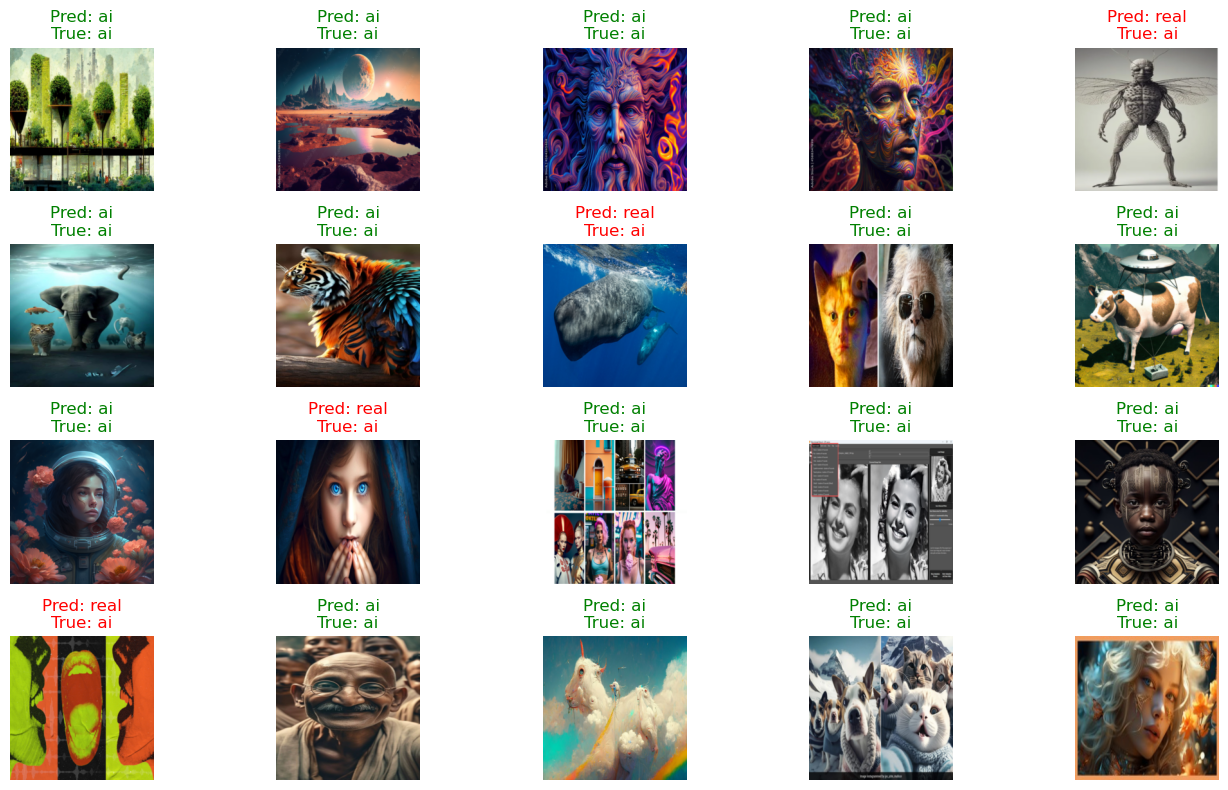

In [21]:
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

class_names = train_dataset.classes  #

mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).to(device)

batch_size = images.size(0)          
num_images = min(20, batch_size)     

plt.figure(figsize=(14, 8))

for i in range(num_images):
    img = images[i].permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    color = "green" if preds[i] == labels[i] else "red"

    plt.subplot(4, 5, i + 1)
    plt.imshow(img.cpu())
    plt.title(
        f"Pred: {class_names[preds[i].item()]}\n"
        f"True: {class_names[labels[i].item()]}",
        color=color
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [22]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[64 17]
 [22 44]]


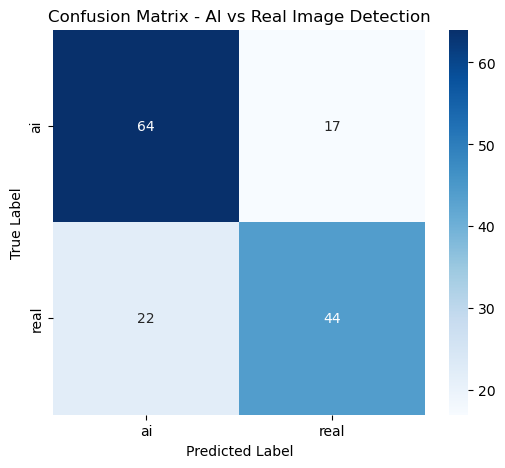

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = train_dataset.classes  # ['ai', 'real']

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - AI vs Real Image Detection")
plt.show()
